# Cine low-pass / SVD comparison

This notebook loads a `.cine`, aligns it with the local `config.json`, extracts a strip, and compares:

- raw aligned strip
- temporal low-pass only
- SVD foreground directly on the raw strip
- 8000 Hz low-pass followed by SVD foreground

Playback uses `play_videos_side_by_side(...)` for quick visual inspection.


In [65]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "OSCC_postprocessing").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(repo_root)


C:\Users\Jiang\Documents\Mie_Postprocessing_Py


## Configuration


In [99]:
CINE_PATH = Path(r"F:\G\Annoyance\T79_Schlieren Cam_5.cine")

FRAME_LIMIT = 400
FPS = 25_000.0

VIDEO_STRIP_RELATIVE_HEIGHT = 1.0
ROW_SLICE = None
COL_SLICE = None

LOW_PASS_ONLY_HZ = 3000.0
LOW_PASS_BEFORE_SVD_HZ = 6000.0
LOW_PASS_ORDER = 2
CHUNK_PIXELS = 16_384

SVD_RANK = 3
SVD_BKG_FRAME_LIMIT = 20

DISPLAY_Q_MIN = 10.0
DISPLAY_Q_MAX = 99
PLAYBACK_INTV_MS = 30
SVD_GAIN = 10.0

assert CINE_PATH.exists(), f"File not found: {CINE_PATH}"


## Imports and helpers


In [120]:
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.filters.svd_background_removal import cp, svd_foreground_cuda
from OSCC_postprocessing.playback.video_playback import *
from OSCC_postprocessing.rotation.rotate_crop import generate_CropRect
from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import rotate_video_nozzle_at_0_half_numpy
from OSCC_postprocessing.utils.scaling import min_max_scale, robust_scale

try:
    from OSCC_postprocessing.rotation.rotate_with_alignment import rotate_video_nozzle_at_0_half_cupy
except Exception:
    rotate_video_nozzle_at_0_half_cupy = None

plt.rcParams["figure.figsize"] = (8, 6)

def load_processing_config(video_path: Path):
    config_path = video_path.parent / "config.json"
    if not config_path.exists():
        raise FileNotFoundError(f"Missing config.json next to video: {video_path}")
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    required = ["plumes", "offset", "centre_x", "centre_y", "inner_radius", "outer_radius"]
    missing = [key for key in required if key not in cfg]
    if missing:
        raise KeyError(f"config.json missing required fields {missing}: {config_path}")
    return cfg, config_path

def build_aligned_strip(video, cfg, strip_relative_height=1.0):
    n_plumes = int(cfg["plumes"])
    cx = float(cfg["centre_x"])
    cy = float(cfg["centre_y"])
    offset_deg = float(cfg["offset"]) % 360.0
    inner = int(float(cfg["inner_radius"]))
    outer = int(float(cfg["outer_radius"]))

    crop = generate_CropRect(inner, outer, n_plumes, cx, cy)
    frame_h, frame_w = int(video.shape[1]), int(video.shape[2])
    base_crop_h = int(min(max(1, crop[3]), frame_h) / 2)
    crop_h = int(max(1, round(base_crop_h * strip_relative_height)))
    crop_w = int(min(max(1, outer), frame_w))
    out_shape = (crop_h, crop_w)
    calibration_point = (0.0, float(cy))

    if rotate_video_nozzle_at_0_half_cupy is not None and hasattr(cp, "ndarray"):
        try:
            video_gpu = cp.asarray(video, dtype=cp.float32)
            aligned_gpu, _, _ = rotate_video_nozzle_at_0_half_cupy(
                video_gpu,
                (cx, cy),
                offset_deg,
                interpolation="nearest",
                border_mode="constant",
                out_shape=out_shape,
                calibration_point=calibration_point,
                cval=0.0,
                stack=True,
            )
            return cp.asnumpy(aligned_gpu).astype(np.float32, copy=False), "cupy"
        except Exception:
            pass

    aligned_np, _, _ = rotate_video_nozzle_at_0_half_numpy(
        np.asarray(video, dtype=np.float32),
        (cx, cy),
        offset_deg,
        interpolation="nearest",
        border_mode="constant",
        out_shape=out_shape,
        calibration_point=calibration_point,
        cval=0.0,
        stack=True,
    )
    return aligned_np.astype(np.float32, copy=False), "numpy"

def normalize_slice(slc, size):
    if slc is None:
        return slice(0, size)
    start, stop, step = slc.indices(size)
    if step != 1:
        raise ValueError("Only contiguous slices with step=1 are supported")
    if stop <= start:
        raise ValueError(f"Empty slice after normalization: {slc}")
    return slice(start, stop)

def temporal_low_pass_butterworth(video, fps, cutoff_hz=300.0, order=2, chunk_pixels=16_384):
    if video.ndim != 3:
        raise ValueError("video must have shape (frames, height, width)")

    n_frames, height, width = video.shape
    pixel_count = height * width
    nyquist_hz = 0.5 * fps
    if not (0 < cutoff_hz < nyquist_hz):
        raise ValueError(f"cutoff_hz must be between 0 and {nyquist_hz:.3f} Hz")

    sos = butter(order, cutoff_hz, btype="lowpass", fs=fps, output="sos")
    padlen = 3 * (2 * len(sos) + 1)
    if n_frames <= padlen:
        raise ValueError(f"video too short for sosfiltfilt: need > {padlen} frames, got {n_frames}")

    video_2d = np.asarray(video, dtype=np.float32).reshape(n_frames, pixel_count)
    filtered = np.empty_like(video_2d, dtype=np.float32)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop]
        filtered[:, start:stop] = sosfiltfilt(sos, block, axis=0, padtype="odd", padlen=padlen).astype(np.float32, copy=False)

    return filtered.reshape(n_frames, height, width)

def prepare_svd_display(segment, rank, bkg_frame_limit, gain=10.0):
    svd_segment = svd_foreground_cuda(cp.asarray(segment, dtype=cp.float32), rank=rank, bkg_frame_limit=bkg_frame_limit)
    svd_segment = cp.asnumpy(svd_segment).astype(np.float32, copy=False)
    svd_positive = svd_segment.copy()
    svd_positive[svd_positive < 0] = 0
    scaled_svd_segment = min_max_scale(svd_positive).astype(np.float32, copy=False) * gain
    return svd_segment, svd_positive, scaled_svd_segment


## Load, align, and crop


Video Info - Width: 768, Height: 768, Frames: 201


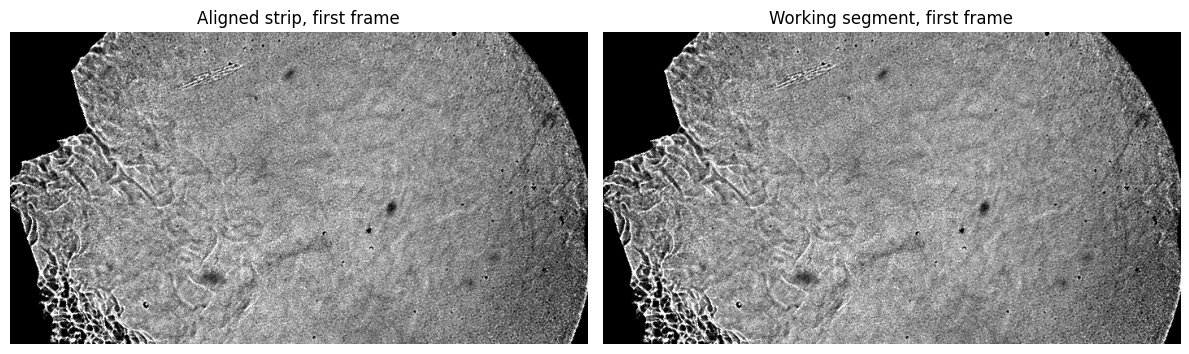

Loaded config: F:\G\Annoyance\config.json
Alignment backend: cupy
aligned_video shape: (201, 384, 711)
segment shape: (201, 384, 711)


In [101]:
video = load_cine_video(str(CINE_PATH), frame_limit=FRAME_LIMIT)
config, config_path = load_processing_config(CINE_PATH)
aligned_video, alignment_backend = build_aligned_strip(video, config, strip_relative_height=VIDEO_STRIP_RELATIVE_HEIGHT)

row_slice = normalize_slice(ROW_SLICE, aligned_video.shape[1])
col_slice = normalize_slice(COL_SLICE, aligned_video.shape[2])
segment = aligned_video[:, row_slice, col_slice].astype(np.float32, copy=False)

frame0 = segment[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(robust_scale(aligned_video[0], q_min=DISPLAY_Q_MIN, q_max=DISPLAY_Q_MAX), cmap="gray")
axes[0].set_title("Aligned strip, first frame")
axes[0].axis("off")

axes[1].imshow(robust_scale(frame0, q_min=DISPLAY_Q_MIN, q_max=DISPLAY_Q_MAX), cmap="gray")
axes[1].set_title("Working segment, first frame")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"Loaded config: {config_path}")
print(f"Alignment backend: {alignment_backend}")
print("aligned_video shape:", aligned_video.shape)
print("segment shape:", segment.shape)


## Process variants


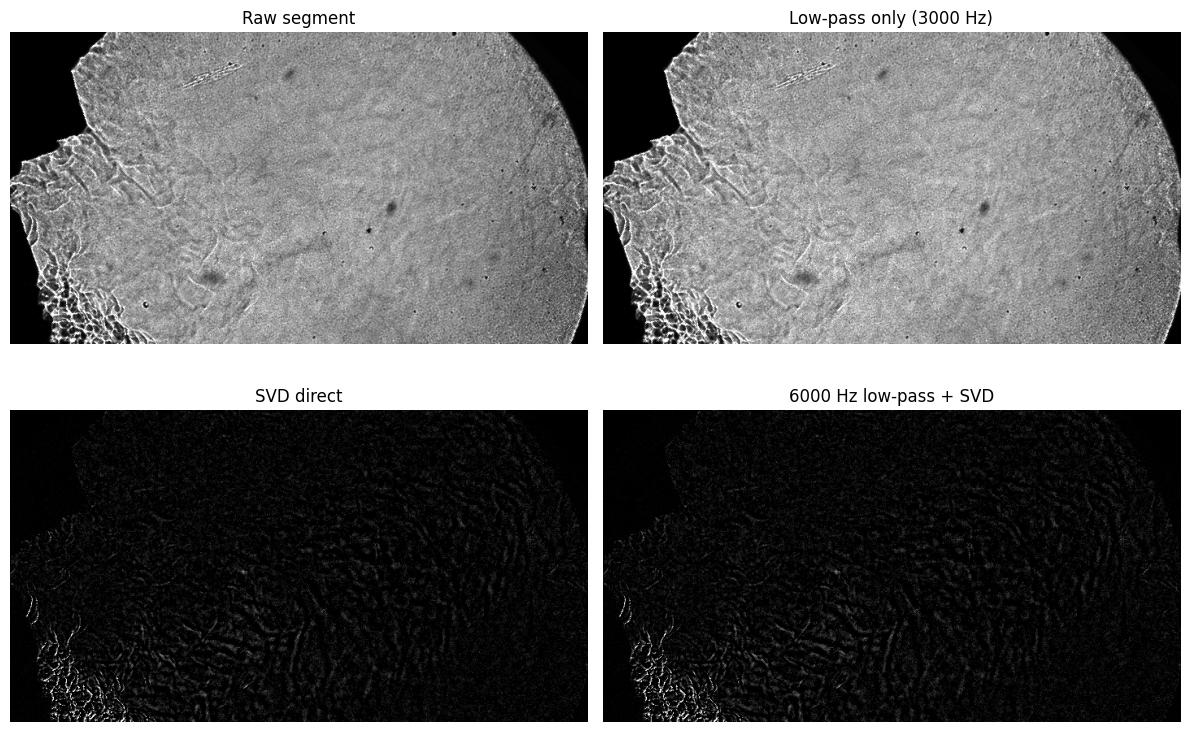

In [102]:
low_pass_only = temporal_low_pass_butterworth(
    segment,
    fps=FPS,
    cutoff_hz=LOW_PASS_ONLY_HZ,
    order=LOW_PASS_ORDER,
    chunk_pixels=CHUNK_PIXELS,
)

svd_direct, svd_direct_positive, svd_direct_scaled = prepare_svd_display(
    segment,
    rank=SVD_RANK,
    bkg_frame_limit=SVD_BKG_FRAME_LIMIT,
    gain=SVD_GAIN,
)

low_pass_before_svd = temporal_low_pass_butterworth(
    segment,
    fps=FPS,
    cutoff_hz=LOW_PASS_BEFORE_SVD_HZ,
    order=LOW_PASS_ORDER,
    chunk_pixels=CHUNK_PIXELS,
)
svd_after_low_pass, svd_after_low_pass_positive, svd_after_low_pass_scaled = prepare_svd_display(
    low_pass_before_svd,
    rank=SVD_RANK,
    bkg_frame_limit=SVD_BKG_FRAME_LIMIT,
    gain=SVD_GAIN,
)

segment_display = robust_scale(segment, q_min=DISPLAY_Q_MIN, q_max=DISPLAY_Q_MAX).astype(np.float32, copy=False)
low_pass_only_display = robust_scale(low_pass_only, q_min=DISPLAY_Q_MIN, q_max=DISPLAY_Q_MAX).astype(np.float32, copy=False)
svd_direct_display = np.clip(svd_direct_scaled, 0.0, 1.0).astype(np.float32, copy=False)
svd_after_low_pass_display = np.clip(svd_after_low_pass_scaled, 0.0, 1.0).astype(np.float32, copy=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(segment_display[0], cmap="gray")
axes[0, 0].set_title("Raw segment")
axes[0, 0].axis("off")

axes[0, 1].imshow(low_pass_only_display[0], cmap="gray")
axes[0, 1].set_title(f"Low-pass only ({LOW_PASS_ONLY_HZ:.0f} Hz)")
axes[0, 1].axis("off")

axes[1, 0].imshow(svd_direct_display[0], cmap="gray")
axes[1, 0].set_title("SVD direct")
axes[1, 0].axis("off")

axes[1, 1].imshow(svd_after_low_pass_display[0], cmap="gray")
axes[1, 1].set_title(f"{LOW_PASS_BEFORE_SVD_HZ:.0f} Hz low-pass + SVD")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


## Quick summary plots


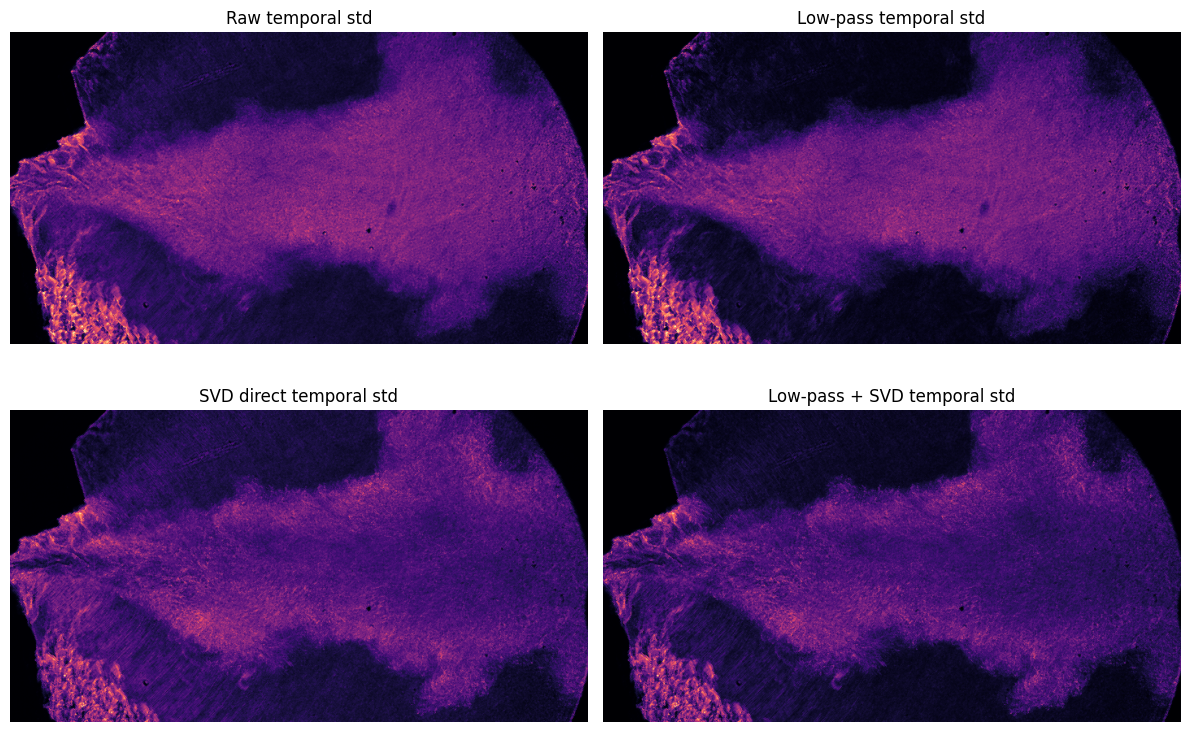

In [103]:
raw_std = segment.std(axis=0)
low_pass_std = low_pass_only.std(axis=0)
svd_direct_std = svd_direct_positive.std(axis=0)
svd_after_low_pass_std = svd_after_low_pass_positive.std(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(raw_std, cmap="magma")
axes[0, 0].set_title("Raw temporal std")
axes[0, 0].axis("off")

axes[0, 1].imshow(low_pass_std, cmap="magma")
axes[0, 1].set_title("Low-pass temporal std")
axes[0, 1].axis("off")

axes[1, 0].imshow(svd_direct_std, cmap="magma")
axes[1, 0].set_title("SVD direct temporal std")
axes[1, 0].axis("off")

axes[1, 1].imshow(svd_after_low_pass_std, cmap="magma")
axes[1, 1].set_title("Low-pass + SVD temporal std")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


## Playback comparison


In [112]:
print("Left to right: raw | low-pass only | SVD direct | 8000 Hz low-pass + SVD")
play_videos_side_by_side(
    (
        segment_display,
        low_pass_only_display,
        svd_direct_display,
        svd_after_low_pass_display,
    ),
    intv=PLAYBACK_INTV_MS,
)


Left to right: raw | low-pass only | SVD direct | 8000 Hz low-pass + SVD


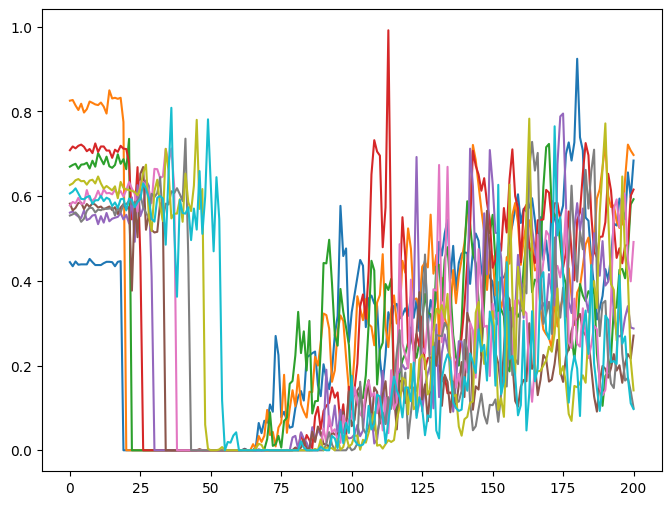

In [127]:
# plt.plot(segment_display[:, 384//2, 711//2])
# plt.plot(svd_direct_display[:, 384//2, 711//2])
# plt.plot(svd_after_low_pass_display[:, 384//2, 711//2])

px_x_list = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

for x in px_x_list:
    plt.plot(segment_display[:, 384//2, x])

In [128]:
neg_diff = np.clip(-(segment[1:] - segment[:-1]), 0, None)
play_video_cv2(min_max_scale(neg_diff))

In [ ]:
arrival_mask = neg_diff > thresh
arrival_time[y, x] = first t where arrival_mask[t, y, x] is True
